# A2.3 – Modelos de Ensamble, SVM y Redes Neuronales
Alumno: Diego Emilio Muñiz Ramirez  
Matrícula: 621784   
Curso: SC3314 – Inteligencia Artificial  
Universidad de Monterrey
Dr. Antonio Torteya

---

## 1. Introducción

En esta actividad se entrena y compara cuatro modelos avanzados de clasificación sobre el **Wine Dataset**: Random Forest, Gradient Boosting, Support Vector Machine (SVM) y una Red Neuronal multicapa (MLP). El objetivo es analizar las diferencias en desempeño, complejidad e interpretabilidad de cada enfoque, sin realizar una búsqueda exhaustiva de hiperparámetros.

## 2. Preparación del escenario experimental

### 2.1 Librerías utilizadas

Se importan las librerías necesarias para el análisis: `pandas` y `numpy` para manejo de datos, `matplotlib` y `seaborn` para visualización, y `scikit-learn` para los modelos de machine learning y métricas de evaluación.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


### 2.2 Descripción del dataset

Se utiliza el **Wine Dataset**, un conjunto de datos clásico de clasificación multiclase que contiene **178 muestras** correspondientes a tres variedades de vino (`class_0`, `class_1`, `class_2`), descritas mediante **13 atributos fisicoquímicos**: alcohol, ácido málico, ceniza, alcalinidad, magnesio, fenoles totales, flavanoides, fenoles no flavanoides, proantocianinas, intensidad de color, tonalidad, OD280/OD315 y prolina.

El dataset no contiene valores nulos, por lo que no se requiere limpieza adicional.

In [ ]:
# Carga del dataset
df = pd.read_csv('wine_dataset.csv')
print(f'Dimensiones del dataset: {df.shape}')
print(f'\nDistribución de clases:\n{df["class_name"].value_counts()}')
print(f'\nValores nulos: {df.isnull().sum().sum()}')
df.head()

Dimensiones del dataset: (178, 15)

Distribución de clases:
class_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

Valores nulos: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


### 2.3 Partición entrenamiento / prueba

Se aplica una división **80/20 con estratificación por clase** (`random_state=42`), garantizando que la distribución de clases sea proporcional en ambos conjuntos. Esta misma partición se utiliza para todos los modelos, asegurando una comparación justa y consistente:

- **Entrenamiento:** 142 muestras (class_0: 47, class_1: 57, class_2: 38)
- **Prueba:** 36 muestras (class_0: 12, class_1: 14, class_2: 10)

In [ ]:
# Separación de features y variable objetivo
X = df.drop(['class', 'class_name'], axis=1)
y = df['class']

# Partición 80/20 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Tamaño de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño de prueba:        {X_test.shape[0]} muestras')
print(f'\nDistribución en entrenamiento: {y_train.value_counts().to_dict()}')
print(f'Distribución en prueba:        {y_test.value_counts().to_dict()}')

Tamaño de entrenamiento: 142 muestras
Tamaño de prueba:        36 muestras

Distribución en entrenamiento: {1: 57, 0: 47, 2: 38}
Distribución en prueba:        {1: 14, 0: 12, 2: 10}


### 2.4 Normalización de datos

Los modelos basados en árboles (Random Forest y Gradient Boosting) no requieren escalado de features. Sin embargo, **SVM y la Red Neuronal son sensibles a la escala**, por lo que se aplica un `StandardScaler` ajustado únicamente sobre el conjunto de entrenamiento. El conjunto de prueba se transforma con esos mismos parámetros para evitar fuga de información (*data leakage*).

In [ ]:
# Normalización (requerida para SVM y Red Neuronal)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # Ajuste y transformación en entrenamiento
X_test_sc  = scaler.transform(X_test)       # Solo transformación en prueba

print('Escalado completado.')
print(f'Media de features (train escalado) ≈ {X_train_sc.mean():.4f}')
print(f'Std de features   (train escalado) ≈ {X_train_sc.std():.4f}')

Escalado completado.
Media de features (train escalado) ≈ -0.0000
Std de features   (train escalado) ≈ 1.0000


## 3. Construcción de modelos

Se entrenaron cuatro modelos. Para cada uno se describen los principales hiperparámetros seleccionados y su justificación. No se realizó búsqueda exhaustiva, las decisiones son razonables y coherentes con el tamaño y naturaleza del dataset.

### 3.1 Random Forest

Modelo de ensamble que combina múltiples árboles de decisión entrenados con muestreo bootstrap y selección aleatoria de features. Reduce la varianza mediante promediado.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `n_estimators` | 100 | Buen balance entre varianza y costo computacional |
| `max_depth` | None | Sin límite; el ensamble controla el sobreajuste |
| `random_state` | 42 | Reproducibilidad |

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest entrenado.')

Random Forest entrenado.


### 3.2 Gradient Boosting

Método de ensamble secuencial donde cada árbol corrige los errores del anterior. Utiliza árboles débiles para evitar sobreajuste individual.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `n_estimators` | 100 | 100 etapas de boosting |
| `learning_rate` | 0.1 | Tasa moderada; valores más bajos requieren más estimadores |
| `max_depth` | 3 | Árboles débiles para evitar sobreajuste individual |

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print('Gradient Boosting entrenado.')

Gradient Boosting entrenado.


### 3.3 Support Vector Machine (SVM)

Modelo que busca el hiperplano de máximo margen entre clases. Con el kernel RBF transforma los datos a un espacio de mayor dimensión donde las clases son linealmente separables. Requiere escalado previo.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `C` | 1.0 | Penalización estándar; equilibra margen y errores |
| `kernel` | `'rbf'` | Apropiado para datos con estructura no lineal |
| `gamma` | `'scale'` | Ajuste automático basado en la varianza de las features |

In [ ]:
svm = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
svm.fit(X_train_sc, y_train)
y_pred_svm = svm.predict(X_test_sc)
print('SVM entrenado.')

SVM entrenado.


### 3.4 Red Neuronal (MLP)

Red neuronal multicapa construida desde cero con scikit-learn. La arquitectura piramidal reduce gradualmente la representación de los datos.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `hidden_layer_sizes` | `(64, 32)` | Dos capas ocultas; arquitectura piramidal |
| `activation` | `'relu'` | Evita el problema del gradiente desvaneciente |
| `max_iter` | 500 | Suficientes iteraciones para convergencia en dataset pequeño |

In [ ]:
nn = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
nn.fit(X_train_sc, y_train)
y_pred_nn = nn.predict(X_test_sc)
print('Red Neuronal entrenada.')

Red Neuronal entrenada.


## 4. Evaluación y comparación de desempeño

Para cada modelo se calculan cuatro métricas en el **conjunto de prueba**: accuracy, precisión macro, recall macro y F1-Score macro. Se emplean promedios macro para tratar a cada clase con igual importancia, lo cual es apropiado dado el balance entre clases.

In [ ]:
def evaluar(nombre, y_true, y_pred):
    return {
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall':    recall_score(y_true, y_pred, average='macro'),
        'F1-Score':  f1_score(y_true, y_pred, average='macro')
    }

metricas = pd.DataFrame([
    evaluar('Random Forest',     y_test, y_pred_rf),
    evaluar('Gradient Boosting', y_test, y_pred_gb),
    evaluar('SVM',               y_test, y_pred_svm),
    evaluar('Red Neuronal',      y_test, y_pred_nn),
]).set_index('Modelo')

print('=== Tabla comparativa de métricas (conjunto de prueba) ===')
print(metricas.round(4).to_string())

=== Tabla comparativa de métricas (conjunto de prueba) ===
                   Accuracy  Precision  Recall  F1-Score
Modelo                                                  
Random Forest        1.0000     1.0000  1.0000    1.0000
Gradient Boosting    0.9444     0.9505  0.9429    0.9453
SVM                  0.9722     0.9778  0.9667    0.9710
Red Neuronal         0.9722     0.9778  0.9667    0.9710


El **Random Forest** obtuvo clasificación perfecta (1.0000 en todas las métricas). El SVM y la Red Neuronal alcanzaron idéntico desempeño (accuracy 0.9722, F1 0.9710), cometiendo el mismo error: una muestra de `class_2` clasificada como `class_1`. El Gradient Boosting presentó el menor desempeño relativo (accuracy 0.9444) con dos errores entre las clases 1 y 2. Las diferencias son **marginales**: el peor modelo clasifica correctamente 34 de 36 muestras.

La siguiente figura muestra la comparación visual de las cuatro métricas por modelo.

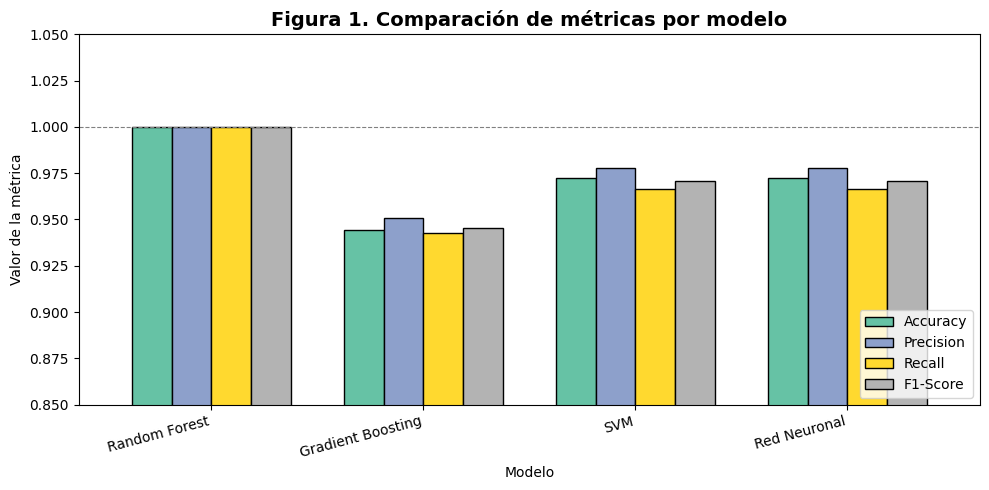

In [ ]:
# Figura 1: Comparación de métricas
fig, ax = plt.subplots(figsize=(10, 5))
metricas.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.75)
ax.set_title('Figura 1. Comparación de métricas por modelo', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor de la métrica')
ax.set_ylim([0.85, 1.05])
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.legend(loc='lower right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 4.1 Matrices de confusión

Las matrices de confusión permiten identificar el patrón de errores de cada modelo. Todos los errores se concentran entre `class_1` y `class_2`, lo que sugiere que estas dos variedades de vino presentan características fisicoquímicas más similares entre sí que con `class_0`.

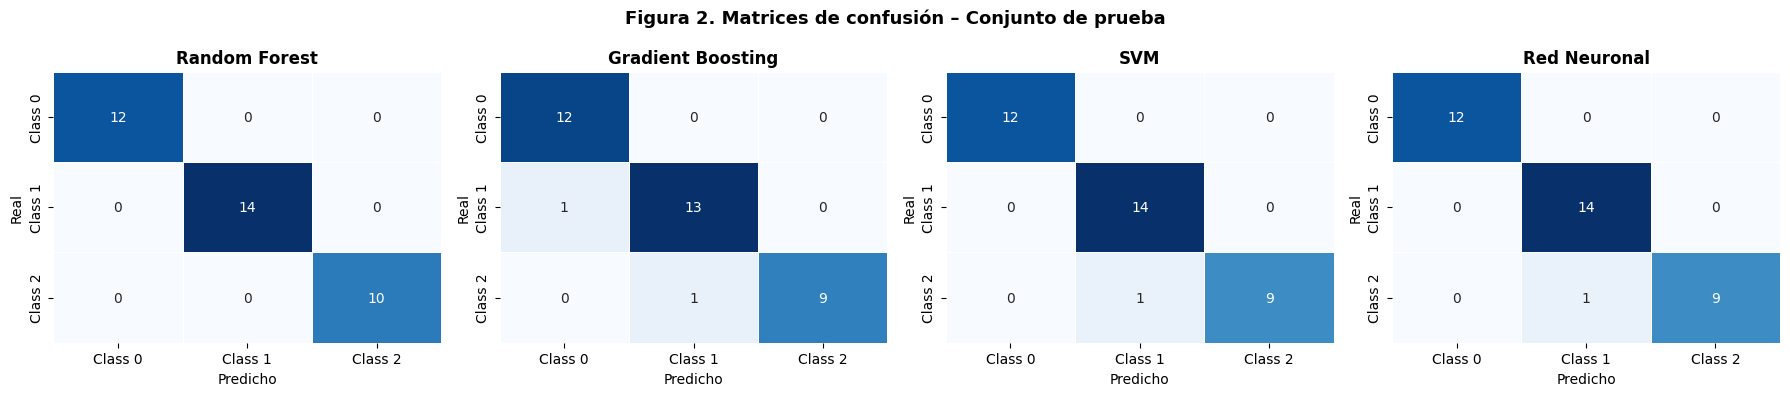

In [ ]:
# Figura 2: Matrices de confusión
modelos_pred = {
    'Random Forest':     y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'SVM':               y_pred_svm,
    'Red Neuronal':      y_pred_nn
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
clases = ['Class 0', 'Class 1', 'Class 2']

for ax, (nombre, y_pred) in zip(axes, modelos_pred.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=clases, yticklabels=clases,
                linewidths=0.5, cbar=False)
    ax.set_title(nombre, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.suptitle('Figura 2. Matrices de confusión – Conjunto de prueba', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Importancia de variables

Una ventaja de los modelos basados en árboles es la disponibilidad de importancia de variables. Las variables más discriminativas son **flavanoides**, **intensidad de color** y **prolina**, mientras que `ash` y `alcalinity_of_ash` contribuyen mínimamente a la separación entre clases.

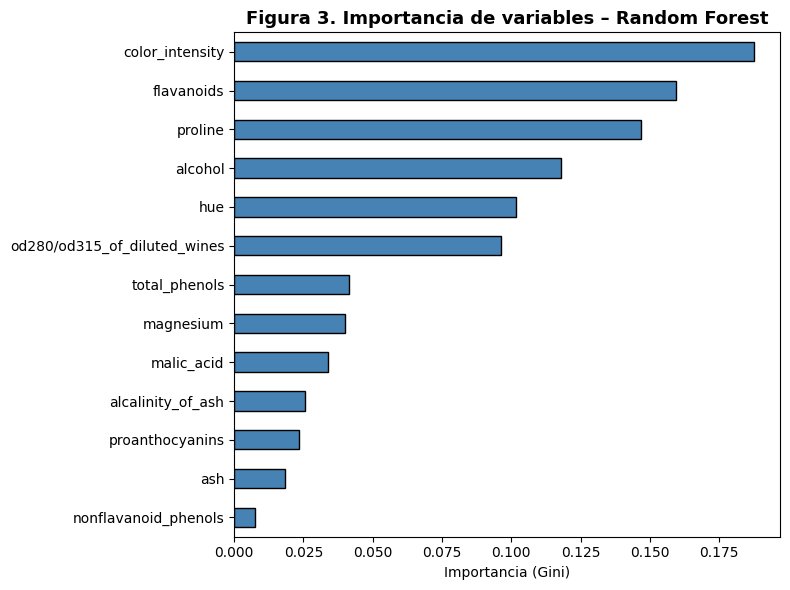

In [ ]:
# Figura 3: Importancia de variables – Random Forest
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Figura 3. Importancia de variables – Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

## 5. Análisis crítico y conclusiones

### Resumen de resultados

| Modelo | Accuracy | F1-Score |
|---|---|---|
| **Random Forest** | **1.0000** | **1.0000** |
| SVM | 0.9722 | 0.9710 |
| Red Neuronal | 0.9722 | 0.9710 |
| Gradient Boosting | 0.9444 | 0.9453 |

### ¿El aumento de complejidad se tradujo en mejoras claras?

No. En este dataset pequeño (178 muestras), el Random Forest alcanzó clasificación perfecta sin necesidad de modelos más complejos. La Red Neuronal y el SVM igualaron el segundo lugar pero no superaron a RF. Esto es consistente con la teoría: en datasets pequeños y bien estructurados, modelos más simples suelen ser suficientes y más estables.

### Riesgo de sobreajuste

La perfección de Random Forest en prueba (1.0000) sobre 178 muestras merece cautela. Es posible que esta partición específica sea especialmente favorable para el modelo. Una evaluación con **k-fold cross-validation** (k=5 o k=10) ofrecería una estimación más robusta del desempeño real en producción.

### Interpretabilidad relativa

- **Random Forest:** Alta — ofrece importancia de variables y árboles visualizables.
- **Gradient Boosting:** Moderada — importancia de variables disponible, pero proceso secuencial difícil de rastrear.
- **SVM:** Baja — la decisión se basa en vectores de soporte en espacio transformado por kernel RBF.
- **Red Neuronal:** La más baja — los pesos no tienen interpretación directa en el dominio del problema.

### ¿Cuándo preferir cada modelo?

- **Random Forest:** Punto de partida ideal. Robusto, rápido e interpretable.
- **Gradient Boosting:** Preferible con datasets grandes, ruidosos o con relaciones complejas.
- **SVM:** Útil en espacios de alta dimensión con clases separables.
- **Red Neuronal:** Justificada con alto volumen de datos y relaciones altamente no lineales.

En conclusión, para el Wine Dataset, el **Random Forest representa el mejor balance** entre desempeño, interpretabilidad y simplicidad. La elección del modelo siempre depende del contexto: volumen de datos, necesidad de interpretabilidad, recursos computacionales y tolerancia al riesgo de sobreajuste.